100%|██████████| 7.83k/7.83k [00:00<00:00, 10.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ninzaami/loan-predication/versions/1


Importing Dependencies - Library to us in this project


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score #To determing how the model is performing

Data Collection and Processing - Cleaning and Handling the dataset

In [ ]:
#Loading the dataset to pandas so the dataset file(csv) can be read
loan_dataset = pd.read_csv('/content/dataset.csv')

In [ ]:
#Viewing the first 5 rows of dataframe
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
#Finding the number of users in this data set and the number of parameters
loan_dataset.shape

(614, 13)

In [ ]:
#There are 614 user and 13 parameteers
#Finding the statistical measures of the dataset
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
#After finding the numerical stats of the dataset, we check for any missing values
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
#Cleaning the missing values from the dataset
loan_dataset = loan_dataset.dropna()

In [ ]:
#To confirm if there are no missing values
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


**LABEL ENCODING**

In [ ]:
#Changing the categories of the Loan Status column to numerical values for easier processing (Y -> 1, N -> 0)
loan_dataset.replace({"Loan_Status": {'N':0, 'Y': 1}}, inplace= True)
#Convert the other categorial column to numerical values too
loan_dataset.replace({"Married": {'No':0, 'Yes': 1},
                     'Gender': {'Male': 1, 'Female': 0},
                      'Self_Employed':{'No': 0, 'Yes': 1},
                      'Property_Area':{'Rural': 0, 'Semiurban': 1, 'Urban': 2},
                      'Education': {'Graduate': 1, 'Not Graduate': 0}},
                     inplace= True)


In [ ]:
#Let's determine the Dependent values of that column
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


In [ ]:
#The '3+' value makes computation difficult so we encode it to 4, meaning all Loan_IDs with 3= dependents will be considered as 4
#Replacing 3+ with 4
loan_dataset = loan_dataset.replace(to_replace='3+', value = 4)
#Checking
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


In [ ]:
#Viewing the first 5 rows of dataframe, after cleaning and label encoding
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1.0,1.0,2,1,1.0,5417,4196.0,267.0,360.0,1.0,2,1


**DATA VISUALIZATION**

<Axes: xlabel='Education', ylabel='count'>

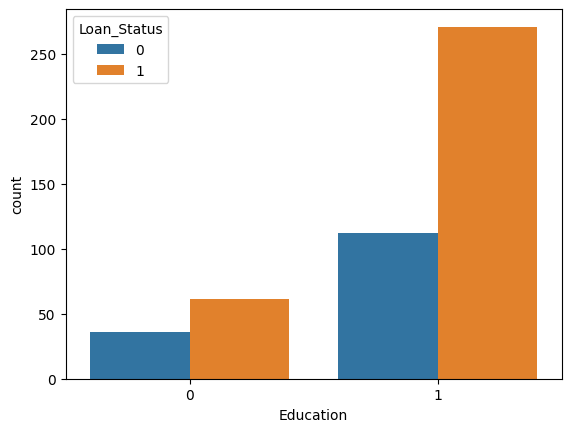

In [ ]:
#Visualizing the relationship between Education and Loan Status
sns.countplot(x ='Education', hue = 'Loan_Status', data = loan_dataset)

*Education Level*

This graph shows that Graduates, have a higher chance of getting a Loan approval than Non-Graduates.


<Axes: xlabel='Married', ylabel='count'>

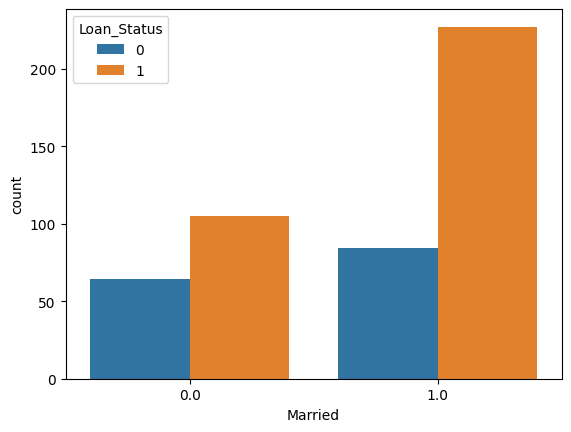

In [ ]:
#Visualizing the relationship between Marriage Status and Loan Status
sns.countplot(x ='Married', hue = 'Loan_Status', data = loan_dataset)

*Marriage Status*

This graph shows that Married individuals have a higher chance of getting their loan approved.


<Axes: xlabel='Self_Employed', ylabel='count'>

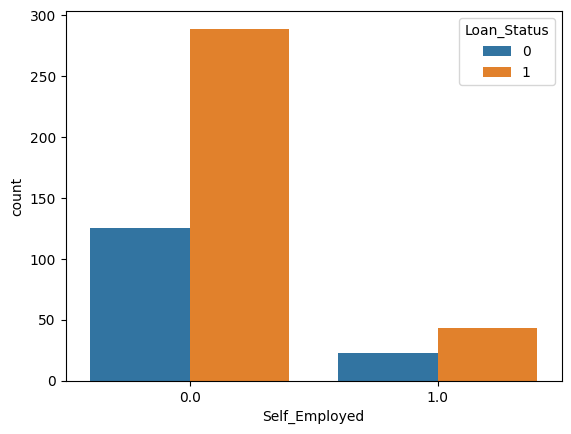

In [ ]:
#Visualizing the relationship between Self-Employment Status and Loan Status
sns.countplot(x ='Self_Employed', hue = 'Loan_Status', data = loan_dataset)

**DATA SPLITTING**

**X - Features:** Parameters used to make the prediction.

**Y - Target:** What the model is supposed to predict, that is the ***Loan Status***

In [ ]:
#Separate tbe data and label.
#Dropping the loan id because it is not a parameter that can influence the loan approval
#Separating the Loan Status (Target)
X = loan_dataset.drop(columns= ['Loan_ID', 'Loan_Status'], axis= 1)
Y = loan_dataset['Loan_Status']
print(X)
print(Y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
1       1.0      1.0          1          1            0.0             4583   
2       1.0      1.0          0          1            1.0             3000   
3       1.0      1.0          0          0            0.0             2583   
4       1.0      0.0          0          1            0.0             6000   
5       1.0      1.0          2          1            1.0             5417   
..      ...      ...        ...        ...            ...              ...   
609     0.0      0.0          0          1            0.0             2900   
610     1.0      1.0          4          1            0.0             4106   
611     1.0      1.0          1          1            0.0             8072   
612     1.0      1.0          2          1            0.0             7583   
613     0.0      0.0          0          1            1.0             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

**TRAIN TEST SPLIT**


The data is split into two.

One dataset is for training the model which is 90% for this model.

The other 10% is for testing the model to see if the model can accurately test after training.

In [ ]:
#Splitting the data for training(90%) and testing(10%)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.1, stratify = Y, random_state= 4)
print(X.shape, X_test.shape, X_train.shape)

(480, 11) (48, 11) (432, 11)


**MODEL TRAINING** - Support Vector Machine Model

For a better line of fit for the Linear Regression as it focuses on the points near the boundaru(Support Vectors) rather that the outliers

In [ ]:
#Classify the model into "Loan Approved" or "Loan Denied"
classifier = svm.SVC(kernel='linear')

#Training the Support Vector Machine Model
classifier.fit(X_train,Y_train)


SVC(kernel='linear')

**MODEL EVALUATION**


Testing the Model


In [ ]:
#Accruaracy Score on Training the Data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy on training the data : ', training_data_accuracy)

Accuracy on training the data :  0.7800925925925926


In [ ]:
#Accruaracy Score on Testing the Data
X_test_prediction = classifier.predict(X_test)
testing_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy on testing the data : ', testing_data_accuracy)

Accuracy on testing the data :  0.7708333333333334


**PREDICTIVE SYSTEM**

In [ ]:
#Creating the predictive system.
def loan_prediction_system(input_features):
    # 1. Defining the feature names in the exact order they appeared in your training data
    feature_names = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                     'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                     'Loan_Amount_Term', 'Credit_History', 'Property_Area']

    # 2. Convert the input list into a Pandas DataFrame with column names
    input_df = pd.DataFrame([input_features], columns=feature_names)

    # 3. Predict
    # If you used a scaler earlier, you would add: input_df = scaler.transform(input_df)
    result = classifier.predict(input_df)

    # 4. Return readable status
    return "Approved" if result[0] == 1 else "Rejected"

# Usage:
new_applicant = [1, 0, 0, 1, 0, 4583, 1508, 128, 360, 1, 1]
print(f"Loan Status: {loan_prediction_system(new_applicant)}")

Loan Status: Approved


Saving the model

In [ ]:
import pickle

# Save the trained model to a file
filename = 'loan_model.sav'
pickle.dump(classifier, open(filename, 'wb'))

# Optional: If you used a scaler, you MUST save it too!
# pickle.dump(scaler, open('scaler.sav', 'wb'))

In [ ]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np
import pandas as pd

# 1. Load the saved model and scaler
model = pickle.load(open('loan_model.sav', 'rb'))
# If you used a scaler:
# scaler = pickle.load(open('scaler.sav', 'rb'))

# 2. Set up the Title and Description
st.title("Loan Eligibility Predictor")
st.write("Enter the applicant's details below to check loan eligibility.")

# 3. Create Input Fields
# We use columns to make it look organized
col1, col2 = st.columns(2)

with col1:
    gender = st.selectbox("Gender", ["Male", "Female"])
    married = st.selectbox("Married", ["No", "Yes"])
    education = st.selectbox("Education", ["Graduate", "Not Graduate"])
    income = st.number_input("Applicant Income", min_value=0)

with col2:
    dependents = st.selectbox("Dependents", ["0", "1", "2", "3+"])
    self_employed = st.selectbox("Self Employed", ["No", "Yes"])
    credit_history = st.selectbox("Credit History", ["Clear", "Outstanding Debts"])
    loan_amount = st.number_input("Loan Amount (in thousands)", min_value=0)

# 4. Map the inputs to match your model's numbers
gender_map = 1 if gender == "Male" else 0
married_map = 1 if married == "Yes" else 0
edu_map = 1 if education == "Graduate" else 0
emp_map = 1 if self_employed == "Yes" else 0
cred_map = 1 if credit_history == "Clear" else 0
dep_map = 4 if dependents == "3+" else int(dependents)

# 5. Prediction Button
if st.button("Check Eligibility"):
    # Create the feature list (Make sure order matches your X_train!)
    features = [gender_map, married_map, dep_map, edu_map, emp_map, income, 0, loan_amount, 360, cred_map, 1]

    # Convert to DataFrame to avoid that "Feature Names" warning
    feature_names = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                     'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                     'Loan_Amount_Term', 'Credit_History', 'Property_Area']

    input_df = pd.DataFrame([features], columns=feature_names)

    # Predict
    prediction = model.predict(input_df)

    if prediction[0] == 1:
        st.success("Congratulations! The loan is likely to be APPROVED.")
    else:
        st.error("The loan is likely to be REJECTED.")

Writing app.py


In [1]:
!git config --global user.email "patrinaoforiamanfo@gmail.com"
!git config --global user.name "Patrina Ofori-Amanfo"

In [2]:
!git clone https://github.com/patrina-oa/loan-prediction-model.git


Cloning into 'loan-prediction-model'...


In [3]:
!ls

drive  loan-prediction-model  sample_data


In [5]:
!ls /content/

drive  loan-prediction-model  sample_data


In [7]:
!ls /content/loan-prediction-model/


In [10]:
!ls /content/drive/MyDrive/Colab\ Notebooks

 Audio_Denoising_ML.ipynb  'Copy of Untitled0.ipynb'   Loan_Predict_Model.ipynb
